In [28]:
import itertools
import time
from typing import TypeAlias, Any, Callable, ParamSpec, Concatenate
from collections.abc import Sequence

import numpy as np
import numpy.random as npr
import numpy.typing as npt

from scipy import integrate as intg

import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.cm as cm

import pynumdiff as ndiff  # Some submodules requrie cvxpy or tqdm
from pynumdiff import smooth_finite_difference as smoothfd
from pynumdiff import polynomial_fit as polyfit
from pynumdiff import basis_fit as basisfit
from pynumdiff import optimize as ndiffopt
from pynumdiff.utils import evaluate as ndiffeval

import importlib
import mysindy
import systems

importlib.reload(mysindy)  # Force reloading module to apply changes
importlib.reload(systems)

<module 'systems' from 'c:\\Users\\yq\\Seafile\\Sync\\Documents\\University of Washington\\2026 Q1 Winter\\ME 571 Data-Driven Dynamic Systems\\ME 571 Final Project\\SINDY-Noise-Investigation\\systems.py'>

In [48]:
dt = 1e-2
num_steps = 3 * 10**3

x_0 = np.array([0, 2, 8])
traj = systems.Trajectory(
    mysindy.lorenz, x_0, dt, num_steps, 0.5
)

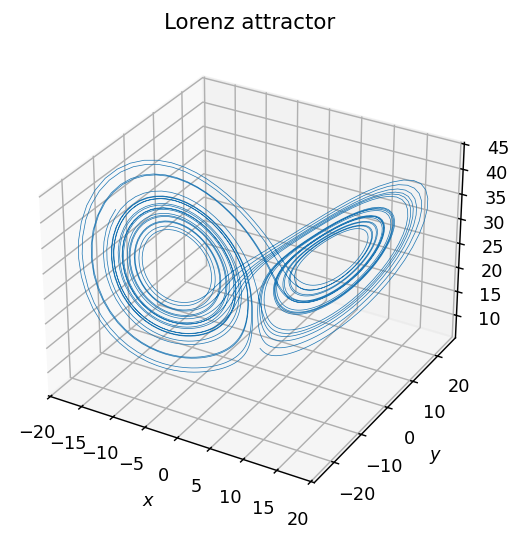

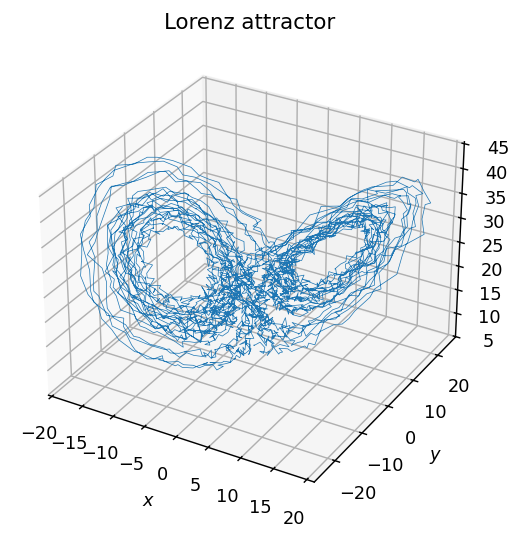

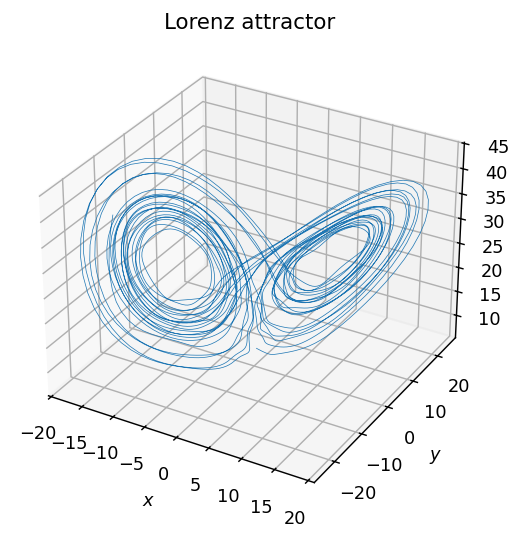

In [50]:
ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x, lw=0.4)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x_noisy, lw=0.4)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x_denoised, lw=0.4)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

# Optimization of denoising hyperparameter


## How to interpret RMSE and $R^2$

From the Komarov, Kutz paper:

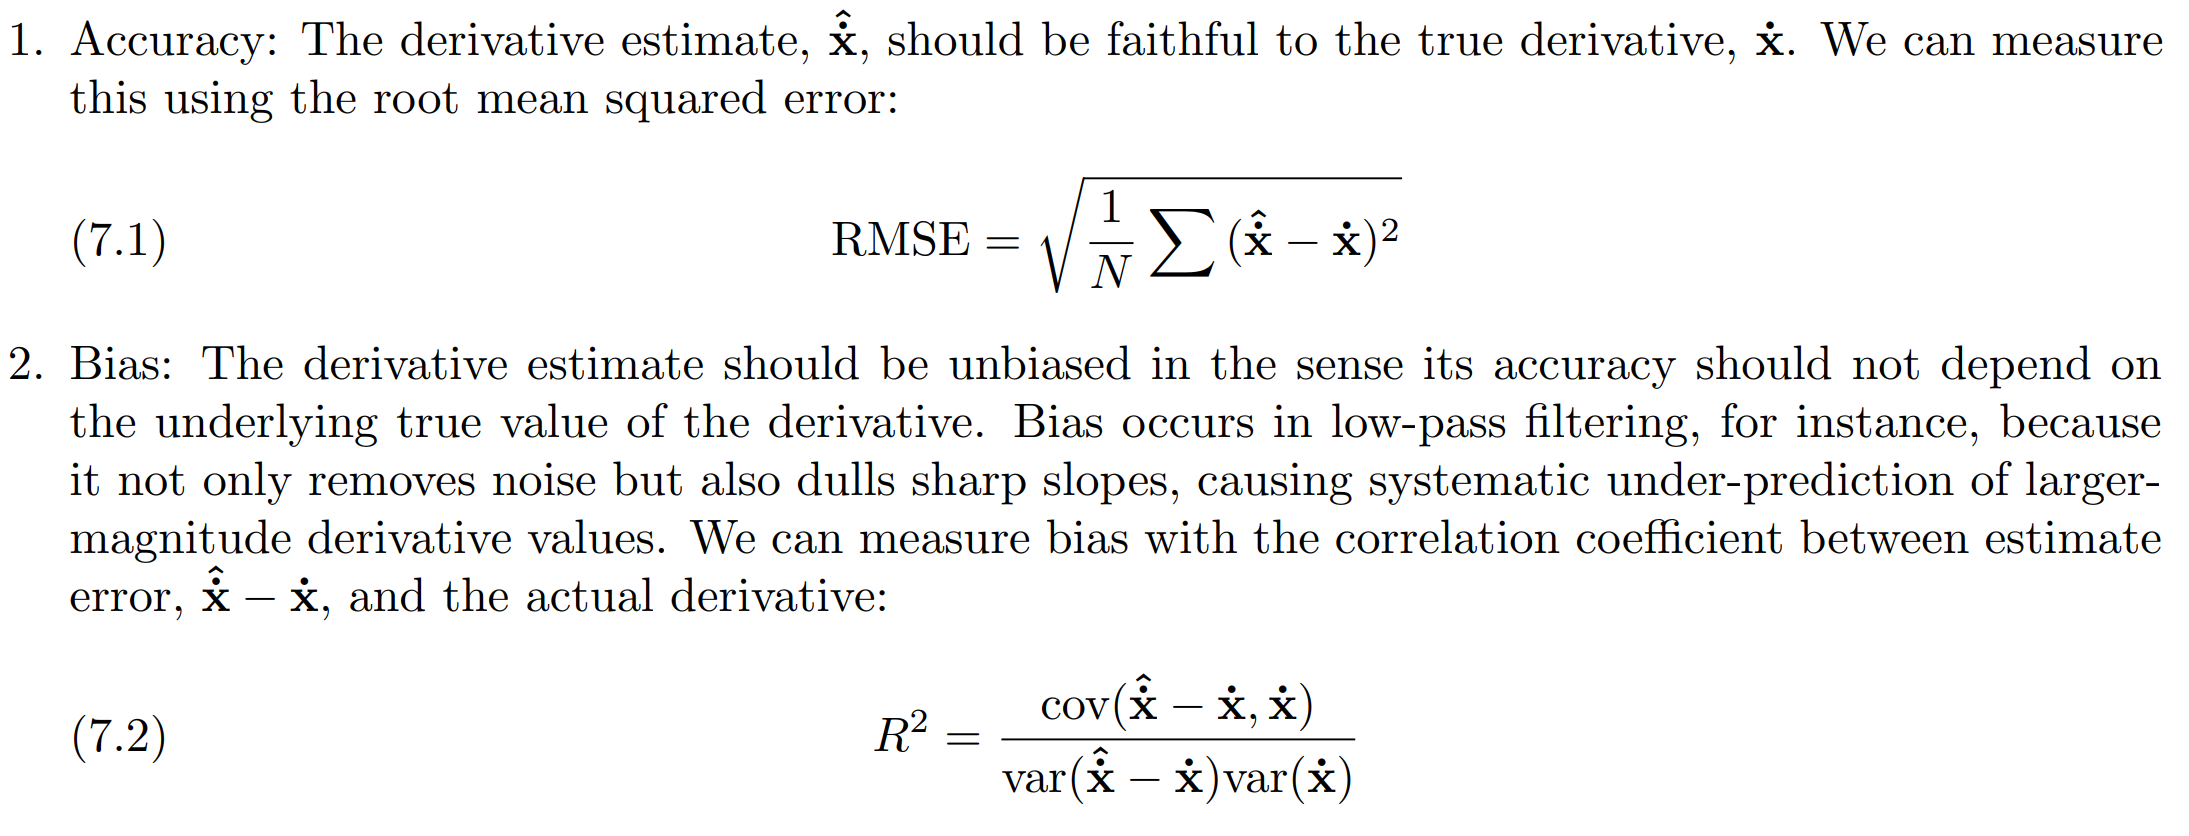

## Estimate $\gamma$

The code is given by [2_optimizing_hyperparameters.ipynb](./pynumdiff%20documentation/2_optimizing_hyperparameters.ipynb).


### Cutoff frequency

Cutoff frequency is an estimation of the upper limit of data signal frequency. To choose it, we perform FFT on $z$, which is given by `traj.x_noisy[2]`.


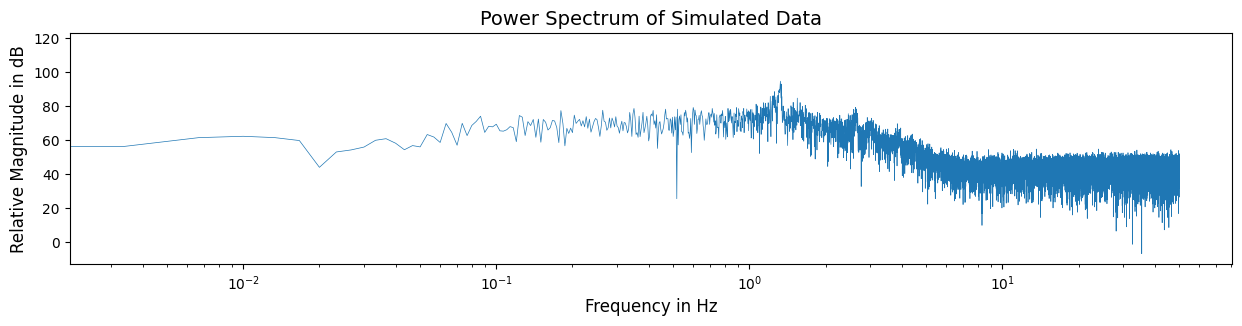

In [4]:
z = traj.x_noisy[2]
z_fft = np.fft.fft(z)
energy_db = 20 * np.log10(np.abs(z_fft))
freqs = np.fft.fftfreq(len(z_fft), dt)
energy_db = energy_db[freqs >= 0]
freqs = freqs[freqs >= 0]

plt.figure(figsize=(15, 3))
plt.semilogx(freqs, energy_db, linewidth=0.5)
plt.title("Power Spectrum of Simulated Data", fontsize=14)
plt.xlabel("Frequency in Hz", fontsize=12)
plt.ylabel("Relative Magnitude in dB", fontsize=12)
plt.show()

Zoom in to $1\text{--}10\,\text{Hz}$:


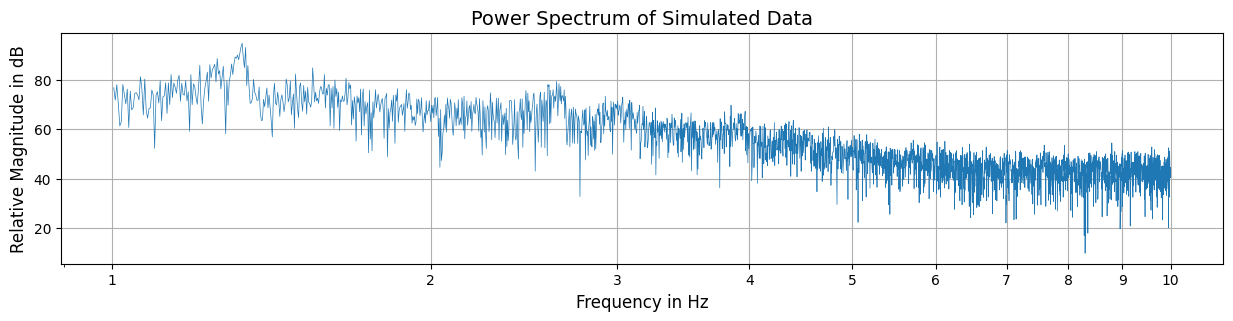

In [5]:
plt.figure(figsize=(15, 3))
freq_plot_range = (1 <= freqs) & (freqs <= 10)
plt.semilogx(freqs[freq_plot_range], energy_db[freq_plot_range], linewidth=0.5)
plt.title("Power Spectrum of Simulated Data", fontsize=14)
plt.xlabel("Frequency in Hz", fontsize=12)
plt.ylabel("Relative Magnitude in dB", fontsize=12)

ticks = np.arange(1, 11)
plt.xticks(ticks=ticks, labels=[str(tick) for tick in ticks])
plt.grid(True)
plt.show()

From this plot, we see that $3\,\text{Hz}$ is a good cutoff frequency.


### Heuristic formula for $\gamma$

$$ \ln\gamma = -1.6 \ln f - 0.71 \ln \Delta t - 5.1 $$

#### Reference

F. van Breugel, B. W. Brunton, and J. N. Kutz. Numerical differentiation of noisy data: A unifying multi-objective optimization framework. *IEEE Access,* 2020.

In [6]:
def estimate_gamma(cutoff_freq, dt):
    log_gamma = -1.6 * np.log(cutoff_freq) - 0.71 * np.log(dt) - 5.1
    gamma = np.exp(log_gamma)
    return gamma

cutoff_freq = 3
gamma = estimate_gamma(cutoff_freq, dt)
print(f"gamma = {gamma}")

gamma = 0.02765057294701546


## Optimization of several denoising methods

Since performing optimization on the whole dataset is time consuming, and we assume the shape of noise is consistent, we use the first 3000 data points for optimization.

In [7]:
def optimize_hparams(method, data_noisy, num_steps_opt, dt, gamma):
    data_sample = data_noisy[0:num_steps_opt]

    tic = time.perf_counter()
    hparams, loss = ndiffopt.optimize(
        method, data_sample, dt, tvgamma=gamma, metric="rmse"
    )
    toc = time.perf_counter() - tic
    print(method.__name__)
    print("---")
    print(f"Optimization run time: {toc:.4g} s")
    print("---")

    print("Optimal parameters:")
    [print(f"{key}: {value}") for key, value in hparams.items()]
    print()

    data_denoised, data_diff_denoised = method(data_noisy, dt, **hparams)

    return hparams, data_denoised, data_diff_denoised, toc


def compare_denoised_to_truth(
    method, ax, num_steps_plot, t_arr, data_truth, data_denoised
):
    t_plot = t_arr[0:num_steps_plot]
    data_truth_plot = data_truth[0:num_steps_plot]
    data_denoised_plot = data_denoised[0:num_steps_plot]

    rmse = ndiffeval.rmse(data_truth, data_denoised)
    err_corr = ndiffeval.error_correlation(data_truth, data_denoised)
    rmse_str = f"{rmse:.4g}"
    err_corr_str = f"{err_corr:.4g}"

    (line_denoised,) = ax.plot(t_plot, data_denoised_plot, linewidth=1)
    line_denoised.set_label("Denoised")
    (line_truth,) = ax.plot(t_plot, data_truth_plot, linewidth=1)
    line_truth.set_label("Ground truth")
    line_denoised.set_zorder(line_truth.get_zorder() + 0.1)
    ax.legend()
    ax.set_title(f"{method.__name__}, RMSE = {rmse_str}, $R^2$ = {err_corr_str}")

    return rmse, err_corr


def optimize_and_plot(
    method, ax, traj: systems.Trajectory, num_steps_opt, num_steps_plot, gamma
):
    t_arr = traj.t_arr
    z_dot = traj.x_dot[2]
    z_noisy = traj.x_noisy[2]

    hparams, z_denoised, z_dot_denoised, toc = optimize_hparams(
        method, z_noisy, num_steps_opt, dt, gamma
    )
    rmse, err_corr = compare_denoised_to_truth(
        method, ax, num_steps_plot, t_arr, z_dot, z_dot_denoised
    )

    return hparams, toc, rmse, err_corr, z_denoised, z_dot_denoised

In [8]:
num_steps_opt = 3000
num_steps_plot = 1000

methods = {
    smoothfd.kerneldiff: "Kernel smoothing",
    smoothfd.butterdiff: "Butterworth smoothing",
    smoothfd.finitediff: "Iterated finite difference",
    polyfit.polydiff: "Sliding polynomial fit",
    polyfit.savgoldiff: "Savitzky-Golay filter",
    basisfit.spectraldiff: "Spectral derivative with tricks",
    basisfit.rbfdiff: "Radial basis functions"
}
num_methods = len(methods)
optimization_args = (traj, num_steps_opt, num_steps_plot, gamma)

kerneldiff
---
Optimization run time: 13.63 s
---
Optimal parameters:
window_size: 3
num_iterations: 7
kernel: mean

butterdiff
---
Optimization run time: 18.37 s
---
Optimal parameters:
cutoff_freq: 0.1499999999999997
num_iterations: 1
filter_order: 2

finitediff
---
Optimization run time: 6.902 s
---
Optimal parameters:
num_iterations: 26
order: 4

polydiff
---
Optimization run time: 87.45 s
---
Optimal parameters:
step_size: 1
degree: 5
window_size: 34
kernel: gaussian

savgoldiff
---
Optimization run time: 14.75 s
---
Optimal parameters:
degree: 8
window_size: 35
smoothing_win: 9

spectraldiff
---
Optimization run time: 16.14 s
---
Optimal parameters:
high_freq_cutoff: 0.1493750000000002
even_extension: True
pad_to_zero_dxdt: False

rbfdiff
---
Optimization run time: 131.5 s
---
Optimal parameters:
sigma: 0.08390625000000003
lmbd: 0.011496093749999999



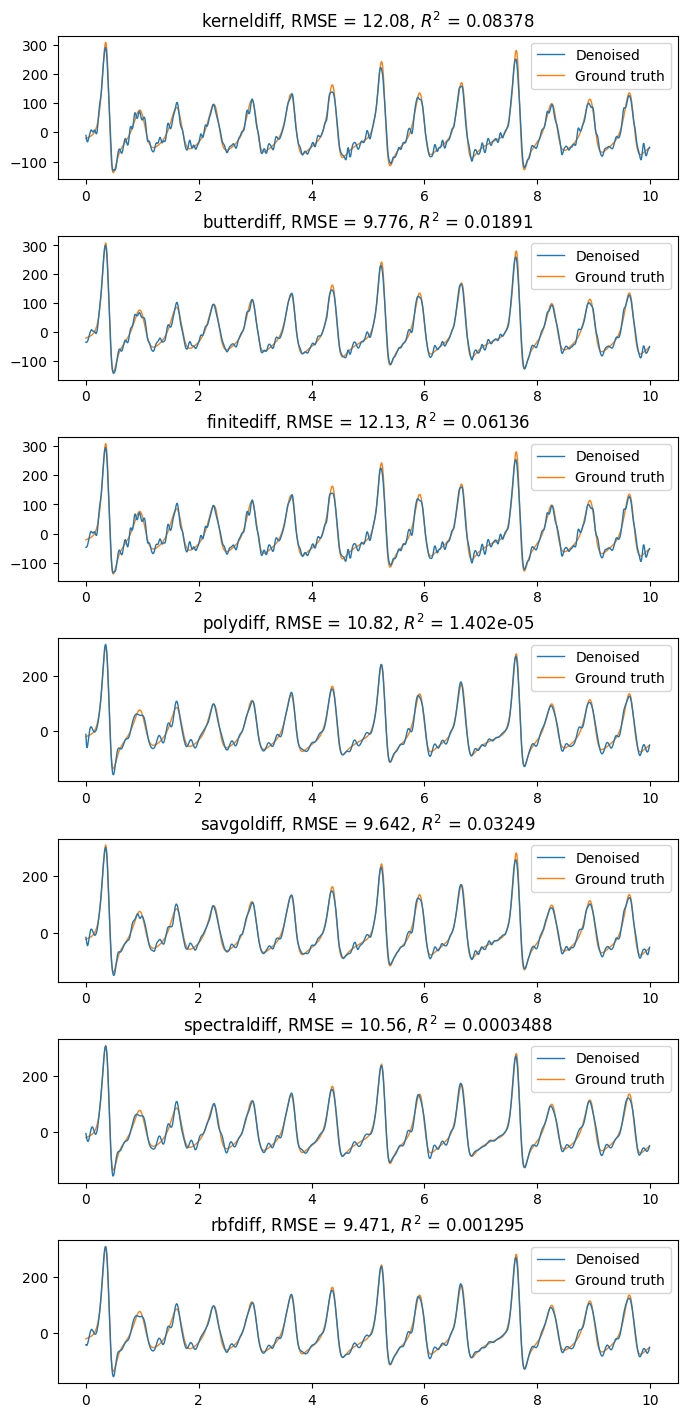

In [9]:
fig = plt.figure(figsize=(8, 2.5 * num_methods))
axs = fig.subplots(nrows=num_methods)
fig.subplots_adjust(hspace=0.4)

results = {
    method.__name__: optimize_and_plot(method, ax, *optimization_args)[:4]
    for method, ax in zip(methods.keys(), axs)
}

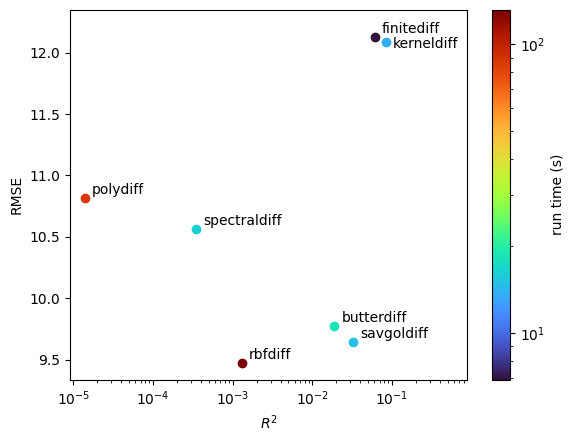

In [16]:
fig, ax = plt.subplots()

times = [results[method][1] for method in results.keys()]
norm = clr.LogNorm(min(times), max(times))
colormap = "turbo"

for method, (param_dict, time, err, err_corr) in results.items():
    ax.scatter(err_corr, err, None, time, norm=norm, cmap=colormap)
    ax.annotate(
        method,
        (err_corr, err),
        xytext=(5, -4 if method == "kerneldiff" else 3),
        textcoords="offset points",
    )

ax.set_xscale("log")
ax.set_xlabel("$R^2$")
ax.set_ylabel("RMSE")

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
fig.colorbar(sm, ax=ax, label="run time (s)")

x_min, x_max = ax.get_xlim()
margin = np.log10(x_max / x_min) * 0.2
ax.set_xlim(x_min, x_max * 10**margin)

y_min, y_max = ax.get_ylim()
margin = (y_max - y_min) * 0.03
ax.set_ylim(y_min, y_max + margin)

plt.show()